# Rubin Donuts with Seeing: Separability, Intra/Extra Asymmetry and Apparent Zernikes (v1)

**Author:** Aaron Roodman (with Claude)
**Date Created:** 2026-09-30
**Last Modified:** 2026-09-30
**Status:** Complete
**Keywords:** seeing, von Karman, Kolmogorov, donut, intra-focal, extra-focal, Huygens, Debye, Danish, Zernike, Rubin

## Description

Adds long-exposure atmospheric seeing to the on-axis Rubin donuts of
`optics_fresnel_rubin_onaxis_v1.ipynb` (design prescription `LSST_r.yaml`, 622 nm,
whole-camera piston of ±1.5 mm, as in full-array-mode (FAM) defocused data).

1. **Separability.** Two ways of adding seeing are tested:
   - the separable approach, which convolves the optics-only donut with the
     atmospheric PSF;
   - the ray-kick approach, which deflects every ray entering the pupil by an angle
     drawn from the atmospheric PSF and then traces it.

   A short derivation shows when the two are equivalent in wave optics. They are then
   compared numerically, in both geometric and wave optics.
2. **Seeing.** A von Kármán PSF with 0.7″ FWHM and a 20 m outer scale is applied to
   the Huygens/Debye diffraction donuts and, for comparison, to geometric donuts.
3. **Intra/extra asymmetry.** Intra- and extra-focal images and their fractional
   difference, plus edge widths.
4. **Apparent Zernikes and seeing.** Each smeared donut is fitted with Danish (a
   geometric donut model convolved with a Kolmogorov kernel), which gives the apparent
   Z4, Z11, Z22 and the apparent seeing FWHM on each side of focus.

**Output:** figures in `optics/output/fresnel/`.

**Based on:** `optics/docs/studies/fresnel_donuts.md`,
`optics_fresnel_rubin_onaxis_v1.ipynb`.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-30 | Aaron Roodman (with Claude) | Initial version |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Separability: derivation](#theory)
5. [Separability: numerical tests](#tests)
6. [Smeared donuts, intra and extra](#smeared)
7. [Edge widths](#edges)
8. [Apparent Zernikes and seeing (Danish fits)](#danish)
9. [Reference TA check and sensitivity to the reference](#ta)
10. [Conclusions](#conclusions)

<a id='params'></a>
## Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================
prescription = 'LSST_r.yaml'
wavelength = 622e-9                 # m
defocus_values = {'intra': -1.5e-3, 'extra': +1.5e-3}   # m, camera piston (FAM)

seeing_fwhm = 0.7                   # arcsec, von Karman FWHM at `wavelength`
outer_scale = 20.0                  # m, von Karman L0

nx_pupil = 2560                     # rays across the pupil grid (Huygens)
dx_image = 0.5e-6                   # m, Huygens sample spacing
npix_image = 4000                   # Huygens samples per side (2.0 mm field)
fine_pixel = 2e-6                   # m, grid on which seeing is applied
npix_fine = 995                     # fine pixels per side (1.99 mm, odd)
pixel_size = 10e-6                  # m, LSSTCam pixel
n_geometric_rays = 20_000_000       # rays per geometric image
aniso_offsets_arcsec = [(3, 0), (0, 3), (-3, -3)]   # field offsets for the isoplanatism test

z_terms = tuple(range(4, 23))       # Noll terms fitted by Danish
output_date = '20260930'

<a id='setup'></a>
## Setup & Imports

In [2]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'common').is_dir())))
from common.utils import setup_plotting, repo_root

root = repo_root()
sys.path.insert(0, str(root / 'optics' / 'code' / 'fresnel'))
import fresnel_donut as fd     # imports finufft before batoid (OpenMP order)
import donut_seeing as ds
import batoid
import galsim
import danish

setup_plotting()
output_dir = root / 'optics' / 'output' / 'fresnel'
output_dir.mkdir(parents=True, exist_ok=True)
factor = int(round(pixel_size / fine_pixel))
npix_stamp = npix_fine // factor
print(f'batoid {batoid.__version__} | galsim {galsim.__version__} | danish {danish.__version__}')
print(f'stamp {npix_stamp} x {npix_stamp} pixels of {pixel_size*1e6:.0f} um')

batoid 0.8.1 | galsim 2.8.5 | danish 1.2.0
stamp 199 x 199 pixels of 10 um


<a id='functions'></a>
## Helper Functions

In [3]:
def huygens_fine(optic, center, theta_x=0.0, theta_y=0.0, weighted=True):
    # Huygens/Debye image binned to the fine grid (unit flux) about `center`.
    rays = fd.trace_pupil_grid(optic, wavelength, nx_pupil, theta_x, theta_y)
    if weighted:
        w, g = fd.debye_weights(rays, nx_pupil)
    else:
        w, g = None, None
    img, xs, ys = fd.huygens_image(rays, wavelength, center, dx_image, npix_image,
                                   weights=w, gamma=g)
    X, Y = np.meshgrid(xs, ys)
    return fd.bin_to_pixels(X.ravel(), Y.ravel(), img.ravel(), center, fine_pixel,
                            npix_fine)


def radial(img, pixel):
    # Azimuthal profile of an odd-sized centred image: mean pixel value per
    # one-pixel-wide annulus (unit total flux, 1/m^2); returns (r [m], profile).
    # Flux/annulus-area would imprint the ~4% ring-to-ring variation in the
    # number of pixel centres per annulus as spurious ringing.
    return fd.pixel_radial_profile(img, pixel)


def flux_moved(a, b):
    # sum |a - b| for unit-flux images, fraction of total flux
    return np.abs(a / a.sum() - b / b.sum()).sum()

<a id='theory'></a>
## 1. Separability: derivation

In the Debye picture the detector field of the telescope is
U(x) = Σ_j c_j exp(i k_j·x), a sum over rays j entering the pupil at u_j. A turbulent
layer multiplies each ray's amplitude by exp(iφ(u_j)). For a statistically
homogeneous layer, the long-exposure average only needs the pupil-plane mutual
coherence, ⟨e^{i[φ(u)−φ(u')]}⟩ = e^{−D(u−u')/2}. This depends only on the separation
u − u', and for a plane wave it is unchanged by free-space propagation, so it holds
for layers at any altitude, not just at the ground (in the weak-scintillation
regime). Its Fourier transform is the atmospheric PSF in angle, P_atm(θ). Therefore

$$\langle I(\mathbf{x})\rangle
= \sum_{j,l} c_j c_l^* e^{-D(\mathbf{u}_j-\mathbf{u}_l)/2} e^{i(\mathbf{k}_j-\mathbf{k}_l)\cdot\mathbf{x}}
= \int d^2\theta\, P_{\rm atm}(\boldsymbol{\theta})\, I_{\boldsymbol\theta}(\mathbf{x}),$$

where $I_\theta$ is the optics-only image of a star at field offset θ. In words:

- **The exact wave-optics ray kick** (every ray gets the tilt of its own plane-wave
  component) is an incoherent average of the optics-only donut over field angle,
  weighted by the atmospheric PSF. This is exact for a long exposure.
- **The separable convolution** replaces $I_\theta(\mathbf{x})$ with
  $I_0(\mathbf{x} - s\boldsymbol\theta)$, where s is the plate scale. It is exact when
  the optics are isoplanatic over the few-arcsec extent of P_atm: the donut shape
  does not change with field angle, and s is the plate scale of the defocused plane.
- **The same argument holds in geometric optics.** A kicked ray lands at the position
  of an unkicked ray from a star at field angle θ.

So the two approaches differ only through anisoplanatism of the optics over a few
arcsec, which is tested below. The long-exposure mean image does not depend on the
turbulence altitude, so a seeing difference between intra- and extra-focal donuts
cannot come from where the turbulence sits. (Finite exposures, and the correlations
between intra and extra speckle patterns, are a separate question.)

<a id='tests'></a>
## 2. Separability: numerical tests

**(a) Isoplanatism of the Huygens donut.** The optics-only Huygens donut is computed
for a star at field offsets of a few arcsec, centred on that star's chief ray, and
compared with the on-axis donut. The chief-ray centring includes the defocused plate
scale.

**(b) Plate scale per side.** Because the beam is non-telecentric (exit pupil ~2.7 m
behind focus), the plate scale of a defocused plane differs from the in-focus value by
~Δz/L_exit ≈ ±0.06% (fraction of the in-focus plate scale, dimensionless).

**(c) Geometric ray kick versus geometric convolution.** 2×10⁷ rays, each deflected by
an angle drawn from the von Kármán PSF, are compared with unkicked rays convolved with
the same PSF. Two independent kicked sets are also compared with each other, to
measure the shot-noise floor.

In [4]:
telescope = batoid.Optic.fromYaml(prescription)
optics = {side: fd.shift_camera(telescope, dz) for side, dz in defocus_values.items()}
atm = ds.vonkarman(seeing_fwhm, wavelength, outer_scale)
r0 = ds.vonkarman_r0(seeing_fwhm, wavelength, outer_scale)
print(f'von Karman: FWHM {atm.calculateFWHM(scale=0.005):.4f} arcsec at {wavelength*1e9:.0f} nm, '
      f'L0 {outer_scale:.0f} m -> r0 {r0*100:.2f} cm at {wavelength*1e9:.0f} nm '
      f'({r0*(500e-9/wavelength)**1.2*100:.2f} cm at 500 nm)')
kolm_same_r0 = galsim.Kolmogorov(lam=wavelength * 1e9, r0=r0)
print(f'Kolmogorov with the same r0: FWHM {kolm_same_r0.calculateFWHM(scale=0.005):.4f} arcsec')

plates = {side: ds.plate_scale(optic, wavelength) for side, optic in optics.items()}
plates['focus'] = ds.plate_scale(telescope, wavelength)
for k, v in plates.items():
    print(f'plate scale {k:6s}: {v:.5f} m/rad = {v*ds.ARCSEC*1e6:.4f} um/arcsec')
print(f"intra/extra plate-scale ratio: {plates['intra']/plates['extra']:.5f} (dimensionless)")

von Karman: FWHM 0.7000 arcsec at 622 nm, L0 20 m -> r0 14.24 cm at 622 nm (10.96 cm at 500 nm)
Kolmogorov with the same r0: FWHM 0.8793 arcsec
plate scale intra : 10.31444 m/rad = 50.0058 um/arcsec
plate scale extra : 10.30542 m/rad = 49.9621 um/arcsec
plate scale focus : 10.30993 m/rad = 49.9840 um/arcsec
intra/extra plate-scale ratio: 1.00087 (dimensionless)


In [5]:
# (a) isoplanatism of the optics-only Huygens donut over a few arcsec
t0 = time.perf_counter()
aniso = {}
huy0 = {}
for side, optic in optics.items():
    c0 = fd.chief_ray_point(optic, wavelength)
    huy0[side] = huygens_fine(optic, c0)
    for ox, oy in aniso_offsets_arcsec:
        th = (ox * ds.ARCSEC, oy * ds.ARCSEC)
        c = fd.chief_ray_point(optic, wavelength, *th)
        img = huygens_fine(optic, c, *th)
        aniso[(side, ox, oy)] = (flux_moved(img, huy0[side]),
                                 flux_moved(ds.rebin(img, factor), ds.rebin(huy0[side], factor)))
print(f'{time.perf_counter()-t0:.0f} s')
print(f"{'side':6s} {'offset [arcsec]':>16s} {'2 um grid: flux moved':>23s} {'10 um pixels: flux moved':>26s}")
for (side, ox, oy), (a, b) in aniso.items():
    print(f'{side:6s} {str((ox, oy)):>16s} {a:23.2e} {b:26.2e}')
print('flux moved = sum |I_theta - I_0| over the grid, fraction of total flux, both centred '
      'on their own chief ray')

78 s
side    offset [arcsec]   2 um grid: flux moved   10 um pixels: flux moved
intra            (3, 0)                5.91e-04                   2.38e-04
intra            (0, 3)                5.91e-04                   2.38e-04
intra          (-3, -3)                8.64e-04                   3.40e-04
extra            (3, 0)                3.71e-04                   1.44e-04
extra            (0, 3)                3.71e-04                   1.44e-04
extra          (-3, -3)                5.65e-04                   2.12e-04
flux moved = sum |I_theta - I_0| over the grid, fraction of total flux, both centred on their own chief ray


In [6]:
# (c) geometric: per-ray kick versus separable convolution
t0 = time.perf_counter()
geo_fine, kick_stamp, kick_stamp_b, geo_conv_stamp = {}, {}, {}, {}
for side, optic in optics.items():
    c = fd.chief_ray_point(optic, wavelength)
    kernel = ds.psf_kernel(atm, fine_pixel, plates[side])
    xg, yg = fd.geometric_positions(optic, wavelength, n_geometric_rays, seed=10)
    geo_fine[side] = fd.bin_to_pixels(xg, yg, None, c, fine_pixel, npix_fine)
    geo_conv_stamp[side] = ds.rebin(ds.smear(geo_fine[side], kernel), factor)
    for seed, store in [(20, kick_stamp), (30, kick_stamp_b)]:
        xk, yk = ds.kicked_positions(optic, wavelength, n_geometric_rays, atm, seed=seed)
        store[side] = fd.bin_to_pixels(xk, yk, None, c, pixel_size, npix_stamp)
print(f'{time.perf_counter()-t0:.0f} s')
for side in optics:
    print(f'{side}: kick vs convolution: flux moved {flux_moved(kick_stamp[side], geo_conv_stamp[side]):.4f}; '
          f'kick vs independent kick (noise floor): {flux_moved(kick_stamp[side], kick_stamp_b[side]):.4f} '
          f'(fraction of total flux, 10 um pixels)')

143 s
intra: kick vs convolution: flux moved 0.0300; kick vs independent kick (noise floor): 0.0424 (fraction of total flux, 10 um pixels)
extra: kick vs convolution: flux moved 0.0305; kick vs independent kick (noise floor): 0.0427 (fraction of total flux, 10 um pixels)


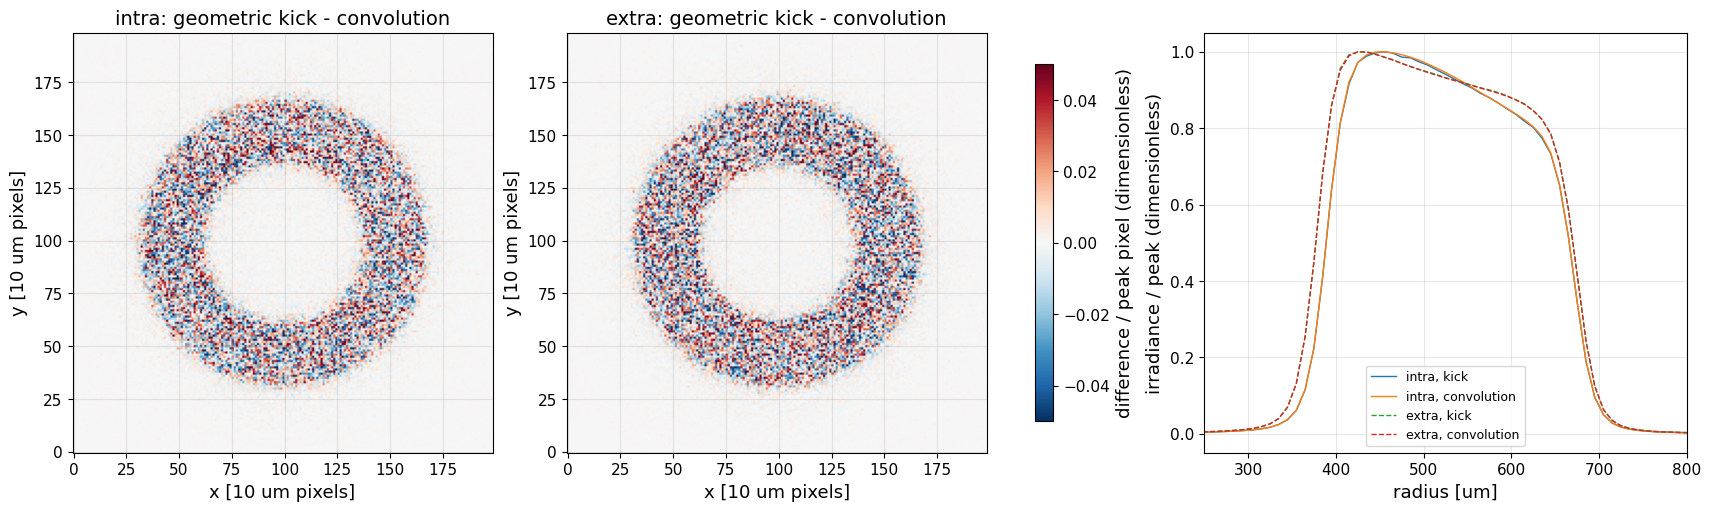

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for a, side in zip(axes[:2], ['intra', 'extra']):
    d = (kick_stamp[side] - geo_conv_stamp[side]) / geo_conv_stamp[side].max()
    im = a.imshow(d, origin='lower', cmap='RdBu_r', vmin=-0.05, vmax=0.05)
    a.set_title(f'{side}: geometric kick - convolution')
    a.set_xlabel('x [10 um pixels]'); a.set_ylabel('y [10 um pixels]')
fig.colorbar(im, ax=axes[:2], label='difference / peak pixel (dimensionless)', shrink=0.85)
for side, ls in [('intra', '-'), ('extra', '--')]:
    for img, lab in [(kick_stamp[side], 'kick'), (geo_conv_stamp[side], 'convolution')]:
        r, p = radial(img, pixel_size)
        axes[2].plot(r * 1e6, p / p.max(), ls, lw=1, label=f'{side}, {lab}')
axes[2].set_xlabel('radius [um]'); axes[2].set_ylabel('irradiance / peak (dimensionless)')
axes[2].set_xlim(250, 800); axes[2].legend(fontsize=9)
fig.savefig(output_dir / f'optics_fresnel_seeing_kick_vs_convolution_{output_date}.png', dpi=110)

<a id='smeared'></a>
## 3. Smeared donuts, intra and extra

Given the tests above, seeing is applied separably. The Debye-weighted Huygens donut
(0.5 µm samples, binned to 2 µm) is convolved with the 0.7″ von Kármán kernel, scaled
by the plate scale of its own defocused plane, then binned to 10 µm pixels. The
geometric donut is treated the same way, for comparison.

Fractional differences, (I_a − I_b) / [(I_a + I_b)/2], are shown where the mean exceeds
5% of its peak: intra versus extra for each model (top two rows). The bottom row shows
(I_Huygens − I_geometric) / I_geometric for each side, where the geometric image exceeds
5% of its peak, with radial profiles. On axis the donut is rotationally symmetric, so the intra
image does not need the 180° flip that an off-axis comparison would.

intra: Huygens vs geometric (both with seeing) flux moved 0.0321 (fraction of total flux)
extra: Huygens vs geometric (both with seeing) flux moved 0.0321 (fraction of total flux)
Huygens + seeing    : intra vs extra flux moved 0.0749 (fraction of total flux)
geometric + seeing  : intra vs extra flux moved 0.0730 (fraction of total flux)


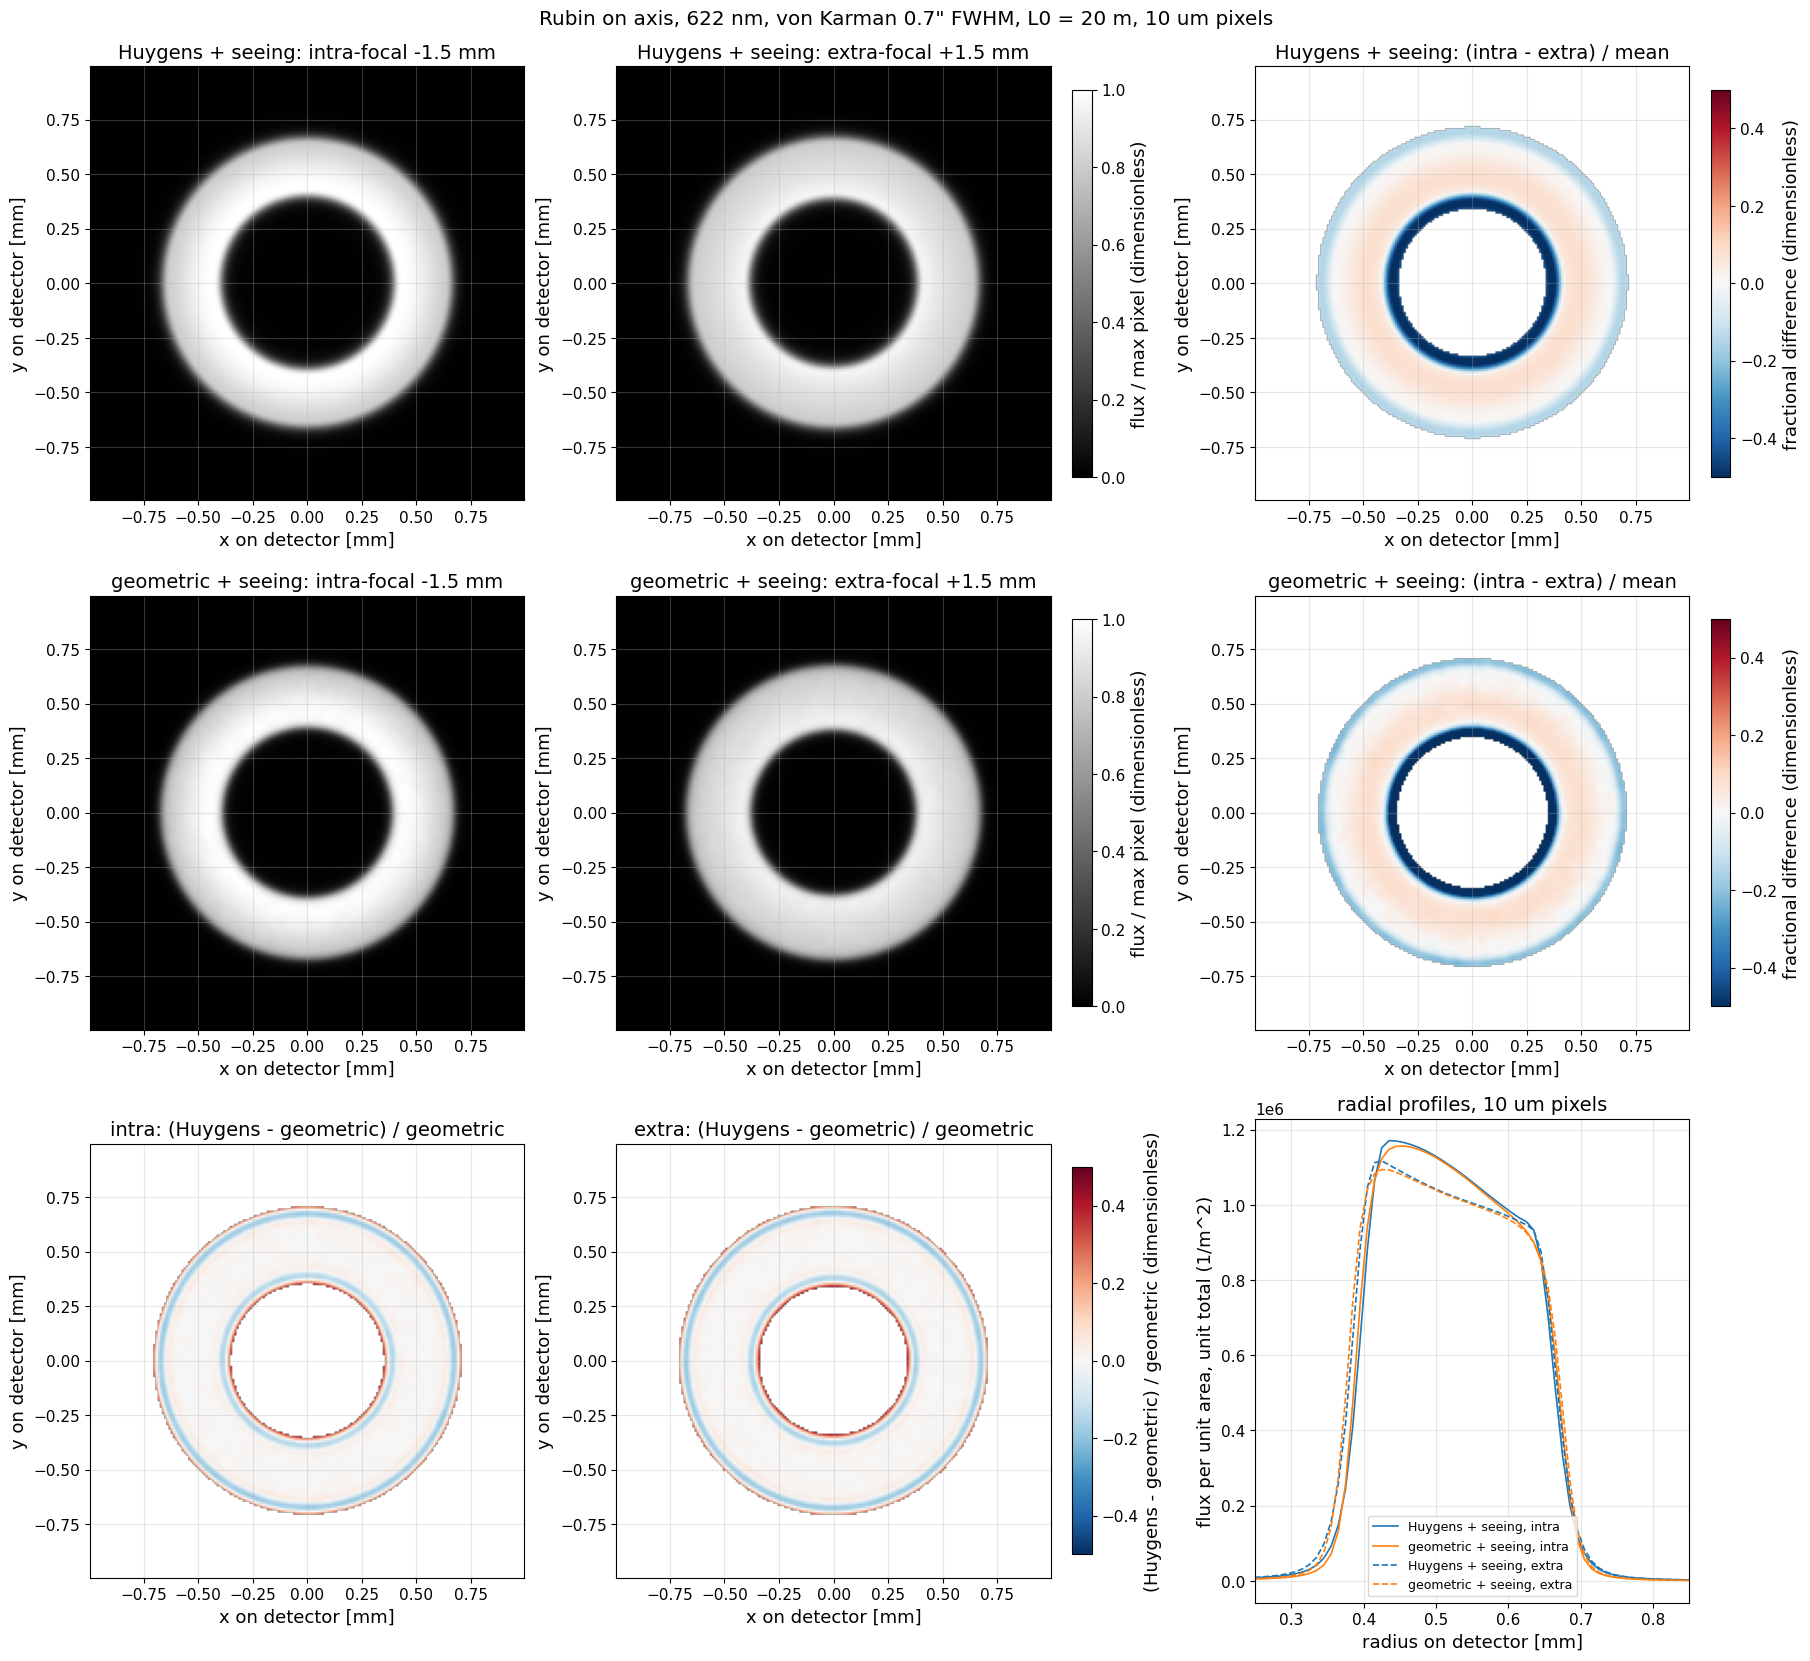

In [8]:
stamps = {'Huygens + seeing': {}, 'geometric + seeing': {},
          'Huygens, no seeing': {}, 'geometric, no seeing': {}}
fine_smeared = {'Huygens + seeing': {}, 'geometric + seeing': {}}
for side in optics:
    kernel = ds.psf_kernel(atm, fine_pixel, plates[side])
    fine_smeared['Huygens + seeing'][side] = ds.smear(huy0[side], kernel)
    fine_smeared['geometric + seeing'][side] = ds.smear(geo_fine[side], kernel)
    stamps['Huygens + seeing'][side] = ds.rebin(fine_smeared['Huygens + seeing'][side], factor)
    stamps['geometric + seeing'][side] = geo_conv_stamp[side]
    stamps['Huygens, no seeing'][side] = ds.rebin(huy0[side], factor)
    stamps['geometric, no seeing'][side] = ds.rebin(geo_fine[side], factor)


def frac_diff(a, b, floor=0.05):
    mean = 0.5 * (a + b)
    out = np.full_like(mean, np.nan)
    m = mean > floor * mean.max()
    out[m] = (a - b)[m] / mean[m]
    return out


ext = np.array([-1, 1, -1, 1]) * npix_stamp / 2 * pixel_size * 1e3
fig, axes = plt.subplots(3, 3, figsize=(18, 16.5))
for row, name in enumerate(['Huygens + seeing', 'geometric + seeing']):
    vmax = max(stamps[name]['intra'].max(), stamps[name]['extra'].max())
    for col, side in enumerate(['intra', 'extra']):
        im = axes[row, col].imshow(stamps[name][side] / vmax, origin='lower', extent=ext,
                                   cmap='gray', vmin=0, vmax=1)
        axes[row, col].set_title(f'{name}: {side}-focal '
                                 f'{defocus_values[side]*1e3:+.1f} mm')
    fig.colorbar(im, ax=axes[row, 1], label='flux / max pixel (dimensionless)', shrink=0.8)
    fd_img = frac_diff(stamps[name]['intra'], stamps[name]['extra'])
    im = axes[row, 2].imshow(fd_img, origin='lower', extent=ext, cmap='RdBu_r',
                             vmin=-0.5, vmax=0.5)
    axes[row, 2].set_title(f'{name}: (intra - extra) / mean')
    fig.colorbar(im, ax=axes[row, 2], label='fractional difference (dimensionless)',
                 shrink=0.8)
for col, side in enumerate(['intra', 'extra']):
    hg = stamps['Huygens + seeing'][side]
    gg = stamps['geometric + seeing'][side]
    rel_hg = np.full_like(gg, np.nan)
    ok = gg > 0.05 * gg.max()
    rel_hg[ok] = (hg - gg)[ok] / gg[ok]
    im = axes[2, col].imshow(rel_hg, origin='lower', extent=ext, cmap='RdBu_r',
                             vmin=-0.5, vmax=0.5)
    axes[2, col].set_title(f'{side}: (Huygens - geometric) / geometric')
fig.colorbar(im, ax=axes[2, 1], label='(Huygens - geometric) / geometric (dimensionless)',
             shrink=0.8)
for side, ls in [('intra', '-'), ('extra', '--')]:
    for name, color in [('Huygens + seeing', 'C0'), ('geometric + seeing', 'C1')]:
        r, p = radial(stamps[name][side], pixel_size)
        axes[2, 2].plot(r * 1e3, p, ls, color=color, lw=1.2,
                        label=f'{name}, {side}')
axes[2, 2].set_xlim(0.25, 0.85)
axes[2, 2].set_title('radial profiles, 10 um pixels')
axes[2, 2].legend(fontsize=9)
for a in axes.ravel()[:-1]:
    a.set_xlabel('x on detector [mm]'); a.set_ylabel('y on detector [mm]')
axes[2, 2].set_xlabel('radius on detector [mm]')
axes[2, 2].set_ylabel('flux per unit area, unit total (1/m^2)')
fig.suptitle(f'Rubin on axis, {wavelength*1e9:.0f} nm, von Karman {seeing_fwhm}" FWHM, '
             f'L0 = {outer_scale:.0f} m, 10 um pixels')
fig.savefig(output_dir / f'optics_fresnel_seeing_intra_extra_{output_date}.png', dpi=110)

for side in ['intra', 'extra']:
    print(f"{side}: Huygens vs geometric (both with seeing) flux moved "
          f"{flux_moved(stamps['Huygens + seeing'][side], stamps['geometric + seeing'][side]):.4f} "
          f"(fraction of total flux)")
for name in ['Huygens + seeing', 'geometric + seeing']:
    print(f"{name:20s}: intra vs extra flux moved "
          f"{flux_moved(stamps[name]['intra'], stamps[name]['extra']):.4f} (fraction of total flux)")

<a id='edges'></a>
## 4. Edge widths

The azimuthal profiles of the smeared donuts on the 2 µm grid, and the 20–80% widths
of the inner (rising) and outer (falling) edges relative to the plateau level. Seeing
blurs the edges by the same kernel on both sides of focus (up to the 0.13% plate-scale
difference), so any intra/extra difference in edge width comes from the optics, either
geometric or diffractive.

model                  side    inner 20-80% [um]  outer 20-80% [um]
Huygens + seeing       intra               31.87              39.02
Huygens + seeing       extra               31.50              36.37


geometric + seeing     intra               28.35              43.11
geometric + seeing     extra               27.28              37.28
(0.7 arcsec = 35.0 um on the detector; sqrt(lambda dz) = 30.5 um)


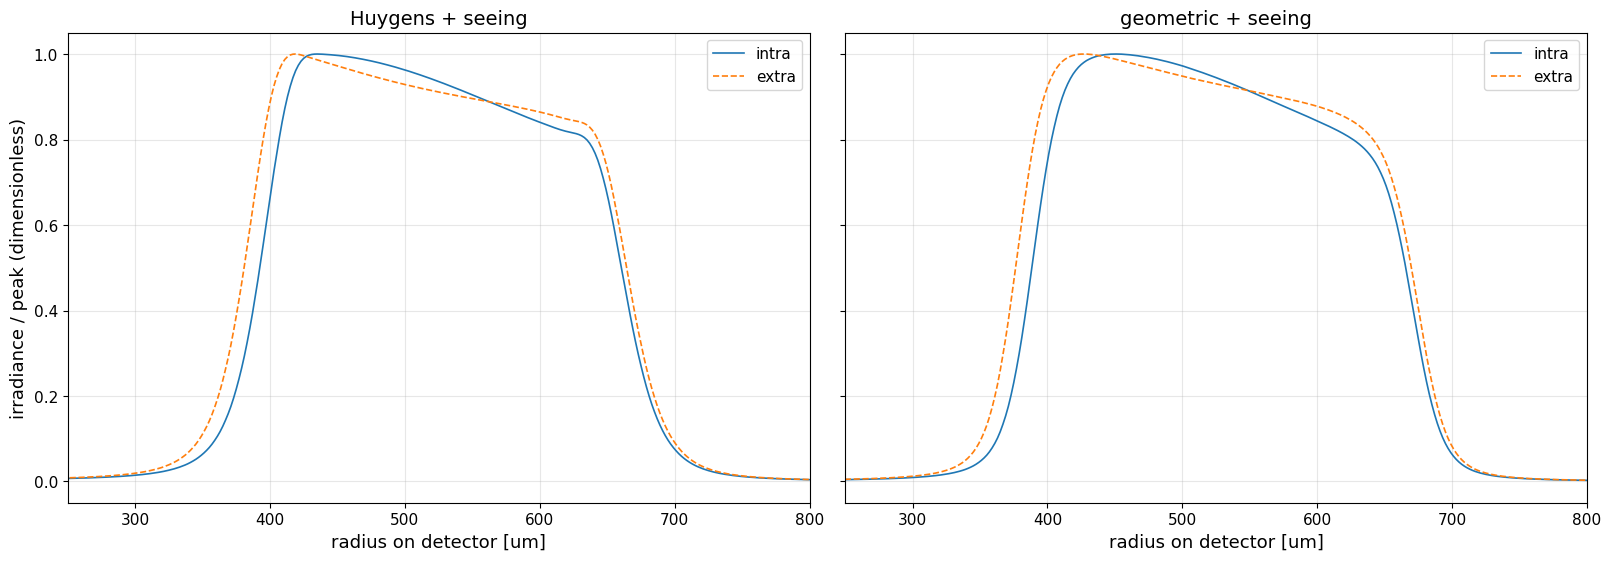

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)
print(f"{'model':22s} {'side':6s} {'inner 20-80% [um]':>18s} {'outer 20-80% [um]':>18s}")
for a, name in zip(axes, ['Huygens + seeing', 'geometric + seeing']):
    for side, ls in [('intra', '-'), ('extra', '--')]:
        r, p = radial(fine_smeared[name][side], fine_pixel)
        a.plot(r * 1e6, p / p.max(), ls, lw=1.2, label=side)
        wi, wo = ds.edge_widths(r, p)
        print(f'{name:22s} {side:6s} {wi*1e6:18.2f} {wo*1e6:18.2f}')
    a.set_title(name)
    a.set_xlabel('radius on detector [um]'); a.set_xlim(250, 800)
    a.legend()
axes[0].set_ylabel('irradiance / peak (dimensionless)')
fig.savefig(output_dir / f'optics_fresnel_seeing_profiles_{output_date}.png', dpi=110)
print(f'(0.7 arcsec = {seeing_fwhm*plates["extra"]*ds.ARCSEC*1e6:.1f} um on the detector; '
      f'sqrt(lambda dz) = {np.sqrt(wavelength*1.5e-3)*1e6:.1f} um)')

<a id='danish'></a>
## 5. Apparent Zernikes and seeing (Danish fits)

Each donut is fitted with Danish's `SingleDonutModel`: a geometric donut model
(`DonutTriangleFactory`, annular pupil with inner/outer radius ratio 0.612) convolved
with a Kolmogorov kernel of free FWHM. The model carries a reference wavefront, the
transverse-aberration (TA) Zernikes of the defocused design optic from
`batoid.analysis.zernikeTA` (jmax = 66), and fits offsets to Z4–Z22. This reference is
Danish's intrinsic TA: Danish maps pupil point u to −f∇W(u), so these coefficients
must reproduce the traced ray positions (checked in the next section). The fits are noise-free,
with the stamps scaled to 10⁶ counts and a sky variance of 100 counts² per pixel.

- A geometric donut plus seeing should return offsets near zero. Its fitted FWHM is
  the Kolmogorov FWHM that best matches the 0.7″ von Kármán kernel, which differs from
  0.7″ because the two profiles have different shapes.
- For the Huygens donuts, the change in fitted FWHM and Zernikes relative to the
  geometric fits is the bias that diffraction introduces into a geometric-model fit.

In [10]:
z_refs = {side: ds.reference_zernikes(optic, wavelength) for side, optic in optics.items()}
fits = {}
t0 = time.perf_counter()
for name in ['geometric + seeing', 'Huygens + seeing', 'geometric, no seeing',
             'Huygens, no seeing']:
    for side in optics:
        fits[(name, side)] = ds.danish_fit(stamps[name][side], z_refs[side], z_terms=z_terms,
                                           fwhm0=0.8 if 'seeing' in name else 0.3)
print(f'{len(fits)} fits in {time.perf_counter()-t0:.0f} s')

hdr = (f"{'model':22s} {'side':6s} {'FWHM [as]':>10s} {'Z4 app [um]':>12s} {'Z11 app [um]':>13s} "
       f"{'Z22 app [um]':>13s} {'dZ4 [nm]':>9s} {'dZ11 [nm]':>10s} {'dZ22 [nm]':>10s} "
       f"{'resid [pk]':>11s}")
print(hdr); print('-' * len(hdr))
for side in optics:
    z = z_refs[side] * 1e6
    print(f"{'reference (zernikeTA)':22s} {side:6s} {'':>10s} {z[4]:12.4f} {z[11]:13.4f} {z[22]:13.4f}")
for (name, side), f in fits.items():
    za = f['z_apparent'] * 1e6
    dz = dict(zip(z_terms, f['z_fit'] * 1e9))
    print(f"{name:22s} {side:6s} {f['fwhm']:10.4f} {za[4]:12.4f} {za[11]:13.4f} {za[22]:13.4f} "
          f"{dz[4]:9.2f} {dz[11]:10.2f} {dz[22]:10.2f} {f['resid_rms']:11.4f}")
print('Z app: apparent coefficient = reference + fitted offset, um of wavefront (Noll, '
      'annular eps 0.612); dZ: fitted offset, nm of wavefront; FWHM: fitted Kolmogorov '
      'FWHM, arcsec; resid: rms(model - data) / peak pixel')

8 fits in 8 s
model                  side    FWHM [as]  Z4 app [um]  Z11 app [um]  Z22 app [um]  dZ4 [nm]  dZ11 [nm]  dZ22 [nm]  resid [pk]
-----------------------------------------------------------------------------------------------------------------------------
reference (zernikeTA)  intra                 -23.7904       -0.1631       -0.0195
reference (zernikeTA)  extra                  23.7226        0.2669       -0.0110
geometric + seeing     intra      0.7529     -23.7905       -0.1640       -0.0196     -0.03      -0.83      -0.14      0.0025
geometric + seeing     extra      0.7539      23.7223        0.2678       -0.0111     -0.24       0.91      -0.11      0.0026
Huygens + seeing       intra      0.8239     -23.7825       -0.1282       -0.0204      7.98      34.92      -0.92      0.0095
Huygens + seeing       extra      0.8234      23.7183        0.2308       -0.0103     -4.32     -36.06       0.64      0.0100
geometric, no seeing   intra      0.0504     -23.7860       -0.163

model                   FWHM intra - extra [as]  dZ4 i-e [nm]  dZ11 i-e [nm]  dZ22 i-e [nm]  mean dZ11 [nm]  mean dZ22 [nm]
geometric + seeing                      -0.0011          0.21          -1.75          -0.03            0.04           -0.12
Huygens + seeing                         0.0006         12.30          70.98          -1.57           -0.57           -0.14
geometric, no seeing                     0.0004         -3.96          -0.26           0.53            0.13           -0.89
Huygens, no seeing                      -0.0024        -62.75         155.62           2.57           -0.89            0.69
i-e: intra minus extra; mean: average of intra and extra fitted offsets, which is what a combined intra+extra wavefront estimate would carry as a bias; nm of wavefront


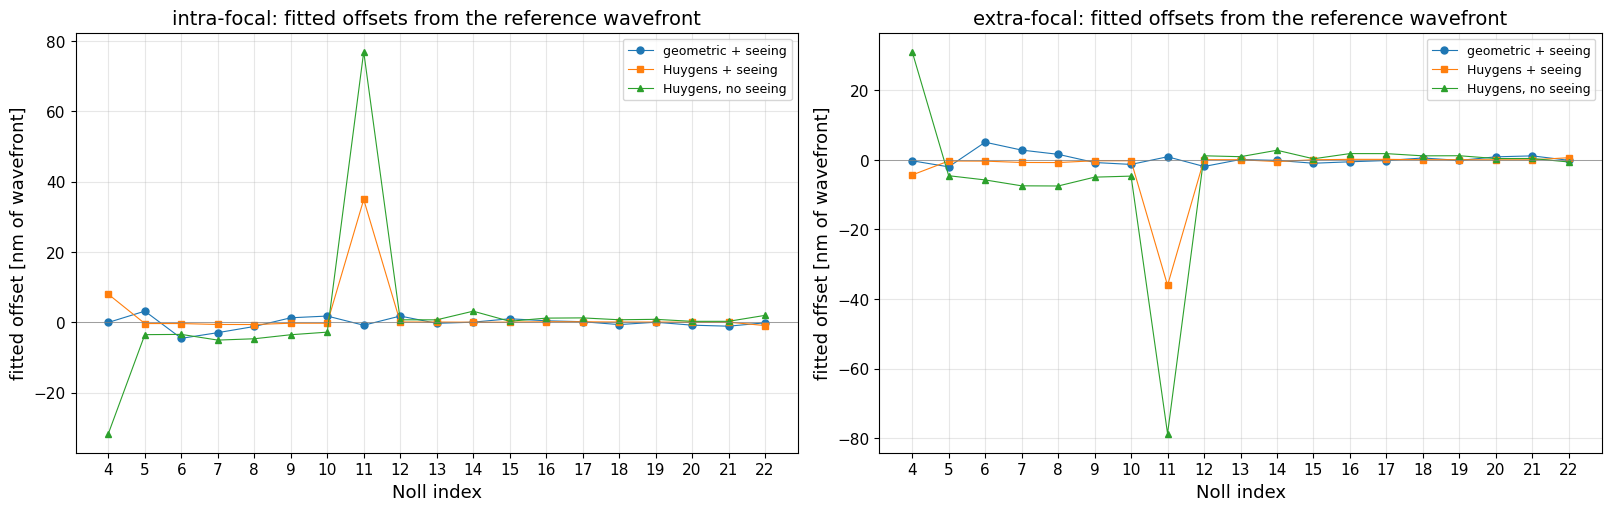

In [11]:
print(f"{'model':22s} {'FWHM intra - extra [as]':>24s} {'dZ4 i-e [nm]':>13s} {'dZ11 i-e [nm]':>14s} "
      f"{'dZ22 i-e [nm]':>14s} {'mean dZ11 [nm]':>15s} {'mean dZ22 [nm]':>15s}")
for name in ['geometric + seeing', 'Huygens + seeing', 'geometric, no seeing',
             'Huygens, no seeing']:
    fi, fe = fits[(name, 'intra')], fits[(name, 'extra')]
    di = dict(zip(z_terms, fi['z_fit'] * 1e9)); de = dict(zip(z_terms, fe['z_fit'] * 1e9))
    print(f"{name:22s} {fi['fwhm'] - fe['fwhm']:24.4f} {di[4] - de[4]:13.2f} "
          f"{di[11] - de[11]:14.2f} {di[22] - de[22]:14.2f} {0.5*(di[11] + de[11]):15.2f} "
          f"{0.5*(di[22] + de[22]):15.2f}")
print('i-e: intra minus extra; mean: average of intra and extra fitted offsets, which is '
      'what a combined intra+extra wavefront estimate would carry as a bias; nm of wavefront')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.array(z_terms)
for a, side in zip(axes, ['intra', 'extra']):
    for name, mk in [('geometric + seeing', 'o'), ('Huygens + seeing', 's'),
                     ('Huygens, no seeing', '^')]:
        a.plot(x, fits[(name, side)]['z_fit'] * 1e9, mk + '-', ms=5, lw=0.8, label=name)
    a.axhline(0, color='gray', lw=0.5)
    a.set_title(f'{side}-focal: fitted offsets from the reference wavefront')
    a.set_xlabel('Noll index'); a.set_ylabel('fitted offset [nm of wavefront]')
    a.set_xticks(x); a.legend(fontsize=9)
fig.savefig(output_dir / f'optics_fresnel_seeing_danish_{output_date}.png', dpi=110)

<a id='ta'></a>
## 6. Reference TA check and sensitivity to the reference

**TA accuracy.** Danish places the ray from pupil point u at −f∇W(u), relative to
the chief ray. The first cell measures how far batoid's traced rays land from those
positions, for TA references truncated at jmax = 28 and 66, and for the wavefront
Zernikes (`batoid.analysis.zernike`) used in place of the TA. This is done for both
defocus geometries: camera piston (full array mode, FAM; the main geometry of this
notebook) and detector-only shift (corner wavefront sensors, CWFS).

**Sensitivity.** The Danish fits are repeated for both geometries (the CWFS stamps are
computed here) with:
- the correct TA;
- the production term list (Noll 4–19, 22–26);
- the other geometry's TA;
- a TA with the defocus-induced terms removed (the intra/extra average of the two TAs,
  with each side's own Z4);
- Z11 fixed at the reference.

These test whether an error in the reference TA can show up as an intra/extra
difference in the fitted seeing FWHM.

In [12]:
geometries = {
    ('camera', 'intra'): optics['intra'], ('camera', 'extra'): optics['extra'],
    ('detector', 'intra'): fd.shift_detector(telescope, -1.5e-3),
    ('detector', 'extra'): fd.shift_detector(telescope, +1.5e-3),
}
ta = {}
print(f"{'geometry':9s} {'side':6s} {'TA Z4':>9s} {'TA Z11':>8s} {'TA Z22':>8s} {'TA Z37':>8s} "
      f"{'WF Z11':>8s} {'rms/max TA28 [um]':>18s} {'rms/max TA66 [um]':>18s} {'rms/max WF [um]':>16s}")
for key, optic in geometries.items():
    ta[key] = ds.reference_zernikes(optic, wavelength, jmax=66)
    ta28 = ta[key].copy(); ta28[29:] = 0.0
    wf = batoid.analysis.zernike(optic, 0.0, 0.0, wavelength, nx=256, jmax=66, eps=0.612) * wavelength
    r28 = ds.ta_ray_residual(optic, wavelength, ta28)
    r66 = ds.ta_ray_residual(optic, wavelength, ta[key])
    rwf = ds.ta_ray_residual(optic, wavelength, wf)
    z = ta[key] * 1e6
    print(f"{key[0]:9s} {key[1]:6s} {z[4]:9.4f} {z[11]:8.4f} {z[22]:8.4f} {z[37]:8.4f} "
          f"{wf[11]*1e6:8.4f} {r28[0]*1e6:8.3f}/{r28[1]*1e6:<9.3f} {r66[0]*1e6:8.3f}/{r66[1]*1e6:<9.3f} "
          f"{rwf[0]*1e6:7.3f}/{rwf[1]*1e6:<8.3f}")
print('Zernikes: um of wavefront (Noll, annular eps 0.612); rms/max: distance between traced '
      'rays and -f grad W, um on the detector')

geometry  side       TA Z4   TA Z11   TA Z22   TA Z37   WF Z11  rms/max TA28 [um]  rms/max TA66 [um]  rms/max WF [um]


camera    intra   -23.7904  -0.1631  -0.0195  -0.0002  -0.1634    0.208/0.928        0.004/0.028       0.083/0.091   


camera    extra    23.7226   0.2669  -0.0110   0.0000   0.2668    0.217/1.030        0.004/0.028       0.049/0.063   


detector  intra   -23.6734  -0.1251  -0.0178  -0.0001  -0.1252    0.210/0.956        0.004/0.028       0.167/0.191   


detector  extra    23.6052   0.2288  -0.0126  -0.0000   0.2289    0.214/1.002        0.004/0.028       0.134/0.168   
Zernikes: um of wavefront (Noll, annular eps 0.612); rms/max: distance between traced rays and -f grad W, um on the detector


In [13]:
# Smeared stamps for the detector-only (CWFS) geometry
t0 = time.perf_counter()
for side in ['intra', 'extra']:
    optic = geometries[('detector', side)]
    c = fd.chief_ray_point(optic, wavelength)
    kernel = ds.psf_kernel(atm, fine_pixel, ds.plate_scale(optic, wavelength))
    H = huygens_fine(optic, c)
    xg, yg = fd.geometric_positions(optic, wavelength, n_geometric_rays, seed=10)
    G = fd.bin_to_pixels(xg, yg, None, c, fine_pixel, npix_fine)
    stamps.setdefault('CWFS Huygens + seeing', {})[side] = ds.rebin(ds.smear(H, kernel), factor)
    stamps.setdefault('CWFS geometric + seeing', {})[side] = ds.rebin(ds.smear(G, kernel), factor)
print(f'{time.perf_counter()-t0:.0f} s')

prod_terms = tuple(list(range(4, 20)) + list(range(22, 27)))
other = {'detector': 'camera', 'camera': 'detector'}


def symmetric_ta(geom, side):
    z = 0.5 * (ta[(geom, 'intra')] + ta[(geom, 'extra')])
    z[4] = ta[(geom, side)][4]
    return z


variants = [
    ('correct TA, Z4-22', lambda g, s: ta[(g, s)], z_terms),
    ('correct TA, production terms', lambda g, s: ta[(g, s)], prod_terms),
    ('other-geometry TA, production', lambda g, s: ta[(other[g], s)], prod_terms),
    ('TA without defocus terms, prod.', symmetric_ta, prod_terms),
    ('correct TA, prod., Z11 fixed', lambda g, s: ta[(g, s)],
     tuple(t for t in prod_terms if t != 11)),
]
stamp_sets = [('camera', 'geometric', stamps['geometric + seeing']),
              ('camera', 'Huygens', stamps['Huygens + seeing']),
              ('detector', 'geometric', stamps['CWFS geometric + seeing']),
              ('detector', 'Huygens', stamps['CWFS Huygens + seeing'])]
hdr = (f"{'geometry':9s} {'donut':10s} {'reference / terms':32s} {'FWHM i':>7s} {'FWHM e':>7s} "
       f"{'i - e':>7s} {'dZ11 i':>7s} {'dZ11 e':>7s} {'resid i':>8s} {'resid e':>8s}")
print(hdr); print('-' * len(hdr))
variant_results = {}
for geom, label, st in stamp_sets:
    for name, zf, terms in variants:
        r = {s: ds.danish_fit(st[s], zf(geom, s), z_terms=terms) for s in ['intra', 'extra']}
        variant_results[(geom, label, name)] = r
        d11 = {s: dict(zip(terms, r[s]['z_fit'] * 1e9)).get(11, np.nan) for s in r}
        print(f"{geom:9s} {label:10s} {name:32s} {r['intra']['fwhm']:7.4f} {r['extra']['fwhm']:7.4f} "
              f"{r['intra']['fwhm'] - r['extra']['fwhm']:7.4f} {d11['intra']:7.1f} {d11['extra']:7.1f} "
              f"{r['intra']['resid_rms']:8.4f} {r['extra']['resid_rms']:8.4f}")
print('FWHM: fitted Kolmogorov FWHM, arcsec; dZ11: fitted Z11 offset from the reference, nm of '
      'wavefront; resid: rms(model - data) / peak pixel')

67 s
geometry  donut      reference / terms                 FWHM i  FWHM e   i - e  dZ11 i  dZ11 e  resid i  resid e
---------------------------------------------------------------------------------------------------------------


camera    geometric  correct TA, Z4-22                 0.7529  0.7539 -0.0011    -0.8     0.9   0.0025   0.0026


camera    geometric  correct TA, production terms      0.7528  0.7539 -0.0011    -0.8     0.9   0.0025   0.0026


camera    geometric  other-geometry TA, production     0.7533  0.7544 -0.0011   -39.0    39.1   0.0025   0.0026


camera    geometric  TA without defocus terms, prod.   0.7537  0.7548 -0.0010  -216.0   216.1   0.0025   0.0026


...

detector  Huygens    correct TA, Z4-22                 0.8232  0.8229  0.0003    34.2   -35.3   0.0094   0.0099


detector  Huygens    correct TA, production terms      0.8232  0.8229  0.0003    34.2   -35.3   0.0094   0.0099


detector  Huygens    other-geometry TA, production     0.8228  0.8225  0.0003    72.3   -73.5   0.0094   0.0099


detector  Huygens    TA without defocus terms, prod.   0.8235  0.8232  0.0003  -142.8   141.7   0.0094   0.0099


detector  Huygens    correct TA, prod., Z11 fixed      0.7987  0.8005 -0.0019     nan     nan   0.0145   0.0152
FWHM: fitted Kolmogorov FWHM, arcsec; dZ11: fitted Z11 offset from the reference, nm of wavefront; resid: rms(model - data) / peak pixel


<a id='conclusions'></a>
## 7. Conclusions

Monochromatic (622 nm), on axis, design prescription, whole camera pistoned ±1.5 mm
(full-array-mode geometry), von Kármán seeing with 0.7″ FWHM and L0 = 20 m
(r0 = 14.2 cm at 622 nm, 11.0 cm at 500 nm). Numbers are from this run.

**Separable convolution is accurate. Ray kicking offers no improvement for the mean
image.**
- For a long exposure, the exact wave-optics ray kick is an average of the optics-only
  donut over field angle, weighted by the atmospheric PSF, for turbulence at any
  altitude. It differs from convolution only through anisoplanatism: ≤ 3.4×10⁻⁴ of
  total flux (Σ|Δ| over 10 µm pixels) for 3–4.2″ offsets.
- A geometric per-ray kick agrees with convolution to within shot noise: Σ|Δ| of 0.030,
  against 0.042 between two independent kicked sets.
- Each defocused plane needs its own plate scale: 10.3144 m/rad intra-focal and
  10.3054 m/rad extra-focal, 0.09% apart. The effect on the kernel is < 0.001″.

**Reference TA.** `zernikeTA` of each camera-pistoned optic with jmax = 66 reproduces
the traced ray positions to 0.004 µm RMS (0.028 µm max). The TA differs between the
two defocus geometries (Z11 −0.163 / +0.267 µm for the camera piston against
−0.125 / +0.229 µm for the detector-only shift), so each geometry needs its own TA.

**Huygens versus geometric, both with seeing.** The images differ by Σ|Δ| = 3.2% of
total flux on each side. Diffraction moves flux out of a ring just inside each
geometric edge and into the shadow just outside it, at both the inner and outer edges
(bottom row of the figure).

**Intra/extra seeing asymmetry: not reproduced.** Fitted Kolmogorov FWHM, intra −
extra (arcsec):

| Case | Camera piston (FAM) | Detector shift (CWFS) |
|---|---|---|
| Huygens + seeing | +0.0006 (0.8239 / 0.8234) | +0.0003 |
| Geometric + seeing | −0.0011 (0.7529 / 0.7539) | −0.0006 |
| Every reference variant tested | ≤ 0.002 in magnitude | ≤ 0.002 in magnitude |

- The observed effect is intra ≈ 0.9″ against extra ≈ 0.8″, i.e. +0.1″, more than
  100 times larger than anything found here.
- Reference-TA errors are absorbed by Z11 (up to ±216 nm), not by the blur.
- Diffraction inflates the fitted FWHM by 0.07″ equally on both sides: the
  diffraction-only donut fits to 0.34″, and 0.824² ≈ 0.753² + 0.34².
- The intra − extra image difference (Σ|Δ| of 7.5% Huygens, 7.3% geometric) is almost
  entirely geometric: different donut radii, and edge widths set by the sign of the
  defocus-induced spherical aberration. Danish's reference already contains that
  geometry.

**Apparent Zernikes** (apparent = TA reference + fitted offset, µm of wavefront):

| | Reference, intra | Apparent, intra | Reference, extra | Apparent, extra |
|---|---|---|---|---|
| Z11 | −0.1631 | −0.1282 | +0.2669 | +0.2308 |
| Z4 | −23.7904 | −23.7825 | +23.7226 | +23.7183 |
| Z22 | −0.0195 | −0.0204 | −0.0110 | −0.0103 |

- **Z11:** fitted offsets +34.9 nm intra and −36.1 nm extra. Diffraction reduces the
  antisymmetric (defocus-induced) part from 0.215 to 0.180 µm; the intra/extra mean
  is unchanged (offset −0.6 nm).
- **Z4:** offsets +8.0 nm intra and −4.3 nm extra.
- **Z22:** offsets within ±1 nm.
- The geometric control's offsets are within ±1 nm.

The companion notebook `optics_fresnel_sensor_iband_v1.ipynb` finds that the silicon
sensor (i band) contributes at most +0.0004″ to intra − extra. In these models —
scalar diffraction, the design optic, one wavelength, a long-exposure atmosphere, a
GalSim CCD — nothing produces a systematic intra/extra difference in fitted blur
above 0.002″.
